In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
df = pd.read_csv("social_media_dataset.csv")

In [3]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (99, 9)

First 5 rows:
   Post_ID Username                                               Text  \
0        1  user001  The new smartphone technology is amazing and i...   
1        2  user002  AI tools are making everyday work faster and e...   
2        3  user003  People are excited about the latest laptop lau...   
3        4  user004  Cloud computing is becoming popular among busi...   
4        5  user005  The new app update has great features #Technol...   

    Platform        Date  Likes  Shares  Comments       Topic  
0    Twitter  2026-07-20    245      38        21  Technology  
1    Twitter  2026-07-21    310      52        34  Technology  
2  Instagram  2026-07-22    198      31        18  Technology  
3   LinkedIn  2026-07-23    165      24        15  Technology  
4    Twitter  2026-07-24    280      44        27  Technology  


In [4]:
print("Column Names:")
print(df.columns)

Column Names:
Index(['Post_ID', 'Username', 'Text', 'Platform', 'Date', 'Likes', 'Shares',
       'Comments', 'Topic'],
      dtype='object')


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Post_ID     0
Username    0
Text        0
Platform    0
Date        0
Likes       0
Shares      0
Comments    0
Topic       0
dtype: int64


In [6]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Post_ID   99 non-null     int64 
 1   Username  99 non-null     object
 2   Text      99 non-null     object
 3   Platform  99 non-null     object
 4   Date      99 non-null     object
 5   Likes     99 non-null     int64 
 6   Shares    99 non-null     int64 
 7   Comments  99 non-null     int64 
 8   Topic     99 non-null     object
dtypes: int64(4), object(5)
memory usage: 7.1+ KB
None


In [7]:
print("\nPlatform Distribution:")
print(df["Platform"].value_counts())


Platform Distribution:
Platform
Twitter      45
Instagram    36
LinkedIn      9
Facebook      9
Name: count, dtype: int64


In [8]:
print("\nTopic Distribution:")
print(df["Topic"].value_counts())


Topic Distribution:
Topic
Technology    11
Sports        11
Music         11
Movies        11
Travel        11
Food          11
Fashion       11
Education     11
Health        11
Name: count, dtype: int64


In [10]:
stop_words = set([
    "a", "an", "the", "and", "or", "is", "are", "was", "were",
    "to", "of", "in", "on", "for", "with", "this", "that",
    "it", "i", "me", "my", "our", "your", "from", "by",
    "be", "has", "have", "had", "very", "more", "most",
    "new", "latest", "today", "every", "people"
])
def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
  text = re.sub(r'@[A-Za-z0-9_]+', ' ', text)
  text = re.sub(r'#', ' ', text)
  text = re.sub(r'[^a-zA-Z\s]', ' ', text)
  words = [
    word for word in text.split()
    if word not in stop_words and len(word) > 2
  ]
  return " ".join(words)

In [11]:

df["Clean_Text"] = df["Text"].apply(clean_text)

print("\nOriginal and Cleaned Text:")
print(df[["Text", "Clean_Text"]].head(10))


Original and Cleaned Text:
                                                Text  \
0  The new smartphone technology is amazing and i...   
1  AI tools are making everyday work faster and e...   
2  People are excited about the latest laptop lau...   
3  Cloud computing is becoming popular among busi...   
4  The new app update has great features #Technol...   
5  Cybersecurity is important for every organizat...   
6  Smart devices are changing modern lifestyles #...   
7  I love the performance of this new processor #...   
8  Machine learning is creating exciting opportun...   
9  The software update fixed many annoying proble...   

                                          Clean_Text  
0  smartphone technology amazing innovative techn...  
1  tools making everyday work faster easier techn...  
2             excited about laptop launch technology  
3  cloud computing becoming popular among busines...  
4               app update great features technology  
5    cybersecurity import

In [12]:

all_words = " ".join(df["Clean_Text"]).split()


word_counts = Counter(all_words)


top_words = pd.DataFrame(
    word_counts.most_common(15),
    columns=["Word", "Frequency"]
)

print("Top 15 Trending Words:")
print(top_words)

Top 15 Trending Words:
             Word  Frequency
0        trending         17
1         fashion         17
2        students         16
3            food         16
4         fitness         15
5         cricket         14
6          travel         14
7      technology         13
8           music         13
9        vacation         12
10      education         12
11         health         12
12         sports         11
13         movies         11
14  entertainment         11


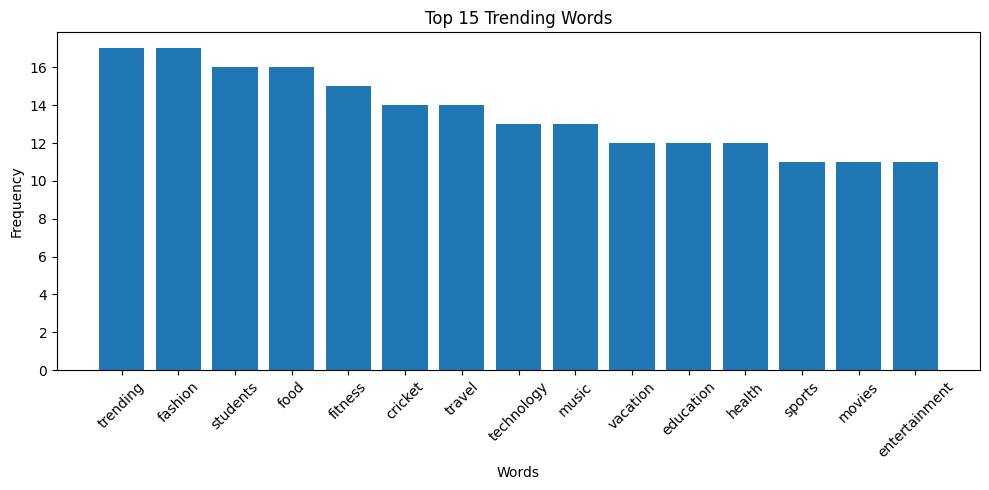

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    top_words["Word"],
    top_words["Frequency"]
)

plt.title("Top 15 Trending Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:

hashtags = re.findall(
    r'#[A-Za-z0-9_]+',
    " ".join(df["Text"])
)


hashtag_counts = (
    pd.Series(hashtags)
    .str.lower()
    .value_counts()
    .head(10)
)

print("Top 10 Hashtags:")
print(hashtag_counts)

Top 10 Hashtags:
#technology       11
#ai               11
#sports           11
#cricket          11
#music            11
#trending         11
#movies           11
#entertainment    11
#travel           11
#vacation         11
Name: count, dtype: int64


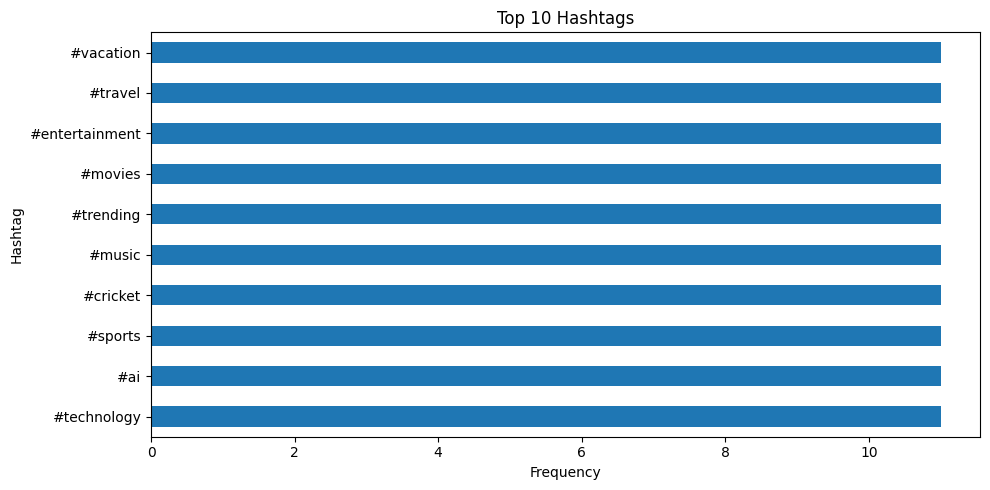

In [15]:
plt.figure(figsize=(10, 5))

hashtag_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Hashtags")
plt.xlabel("Frequency")
plt.ylabel("Hashtag")

plt.tight_layout()
plt.show()

In [16]:
topic_counts = df["Topic"].value_counts()

print("Public Interest by Topic:")
print(topic_counts)

Public Interest by Topic:
Topic
Technology    11
Sports        11
Music         11
Movies        11
Travel        11
Food          11
Fashion       11
Education     11
Health        11
Name: count, dtype: int64


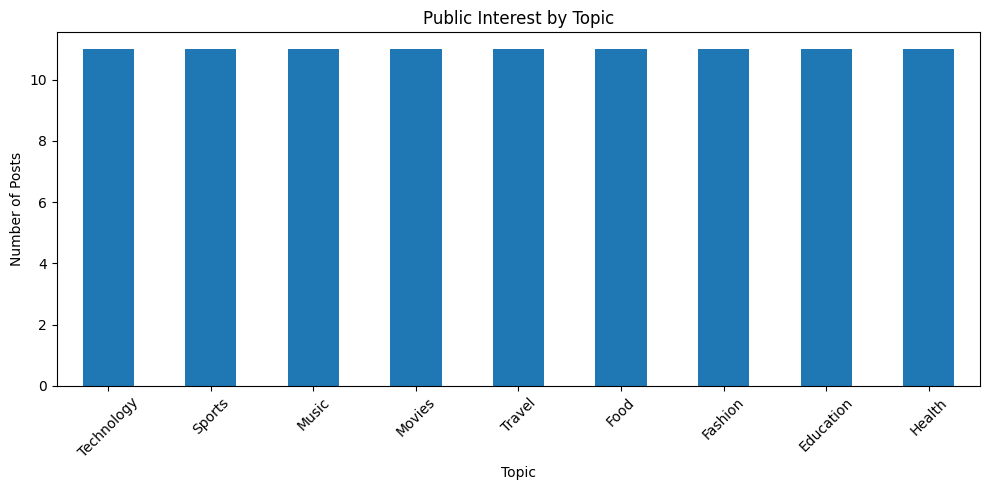

In [17]:
plt.figure(figsize=(10, 5))

topic_counts.plot(kind="bar")

plt.title("Public Interest by Topic")
plt.xlabel("Topic")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:

df["Engagement"] = (
    df["Likes"] +
    df["Shares"] +
    df["Comments"]
)

print(df[
    ["Topic", "Likes", "Shares", "Comments", "Engagement"]
].head())

        Topic  Likes  Shares  Comments  Engagement
0  Technology    245      38        21         304
1  Technology    310      52        34         396
2  Technology    198      31        18         247
3  Technology    165      24        15         204
4  Technology    280      44        27         351


In [19]:
engagement = (
    df.groupby("Topic")["Engagement"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Engagement by Topic:")
print(engagement)

Average Engagement by Topic:
Topic
Sports        486.181818
Music         416.272727
Travel        381.181818
Movies        379.636364
Fashion       367.000000
Food          353.818182
Health        346.454545
Education     301.363636
Technology    299.818182
Name: Engagement, dtype: float64


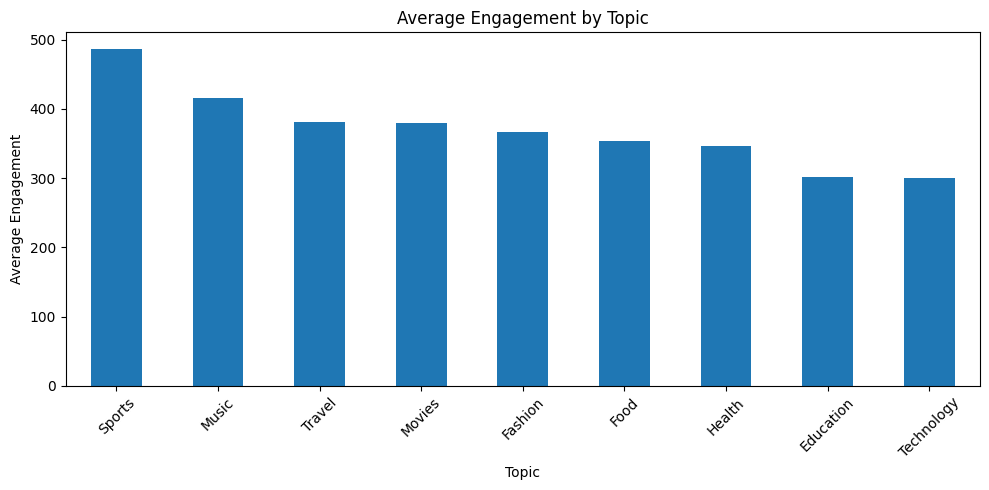

In [20]:
plt.figure(figsize=(10, 5))

engagement.plot(kind="bar")

plt.title("Average Engagement by Topic")
plt.xlabel("Topic")
plt.ylabel("Average Engagement")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:

positive_words = set([
    "amazing", "excellent", "fantastic", "great", "good",
    "love", "loved", "beautiful", "exciting", "wonderful",
    "fun", "brilliant", "awesome", "happy", "helpful",
    "useful", "energetic", "perfect", "delicious",
    "tasty", "stylish", "popular", "memorable",
    "innovative", "impressive"
])


negative_words = set([
    "bad", "boring", "disappointing", "terrible",
    "frustrating", "stressful", "annoying", "expensive",
    "late", "cold", "tasteless", "strange",
    "confusing", "predictable", "loss"
])
def sentiment_analysis(text):

    words = text.split()

    positive_score = sum(
        word in positive_words
        for word in words
    )

    negative_score = sum(
        word in negative_words
        for word in words
    )

    score = positive_score - negative_score

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Clean_Text"].apply(
    sentiment_analysis
)

print(df[
    ["Text", "Sentiment"]
].head(10))

                                                Text Sentiment
0  The new smartphone technology is amazing and i...  Positive
1  AI tools are making everyday work faster and e...   Neutral
2  People are excited about the latest laptop lau...   Neutral
3  Cloud computing is becoming popular among busi...  Positive
4  The new app update has great features #Technol...  Positive
5  Cybersecurity is important for every organizat...   Neutral
6  Smart devices are changing modern lifestyles #...   Neutral
7  I love the performance of this new processor #...  Positive
8  Machine learning is creating exciting opportun...  Positive
9  The software update fixed many annoying proble...  Negative


In [22]:
sentiment_counts = df["Sentiment"].value_counts()

print("Sentiment Distribution:")
print(sentiment_counts)

Sentiment Distribution:
Sentiment
Neutral     44
Positive    40
Negative    15
Name: count, dtype: int64


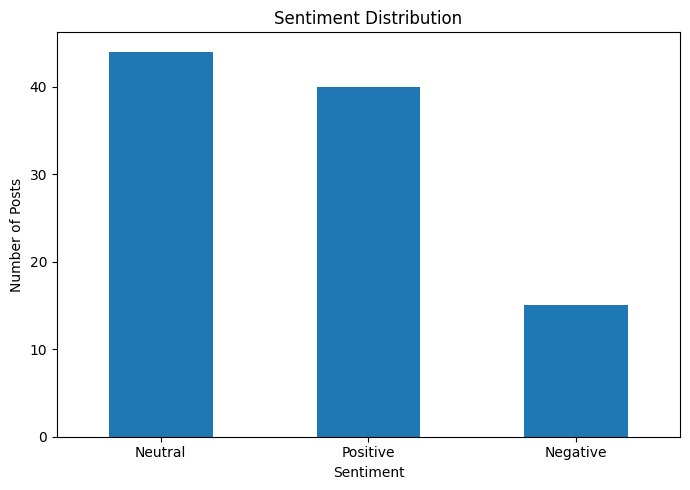

In [23]:
plt.figure(figsize=(7, 5))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
topic_sentiment = pd.crosstab(
    df["Topic"],
    df["Sentiment"]
)

print("Topic-wise Sentiment:")
print(topic_sentiment)

Topic-wise Sentiment:
Sentiment   Negative  Neutral  Positive
Topic                                  
Education          2        5         4
Fashion            2        4         5
Food               3        3         5
Health             1        7         3
Movies             2        4         5
Music              1        6         4
Sports             1        7         3
Technology         1        5         5
Travel             2        3         6


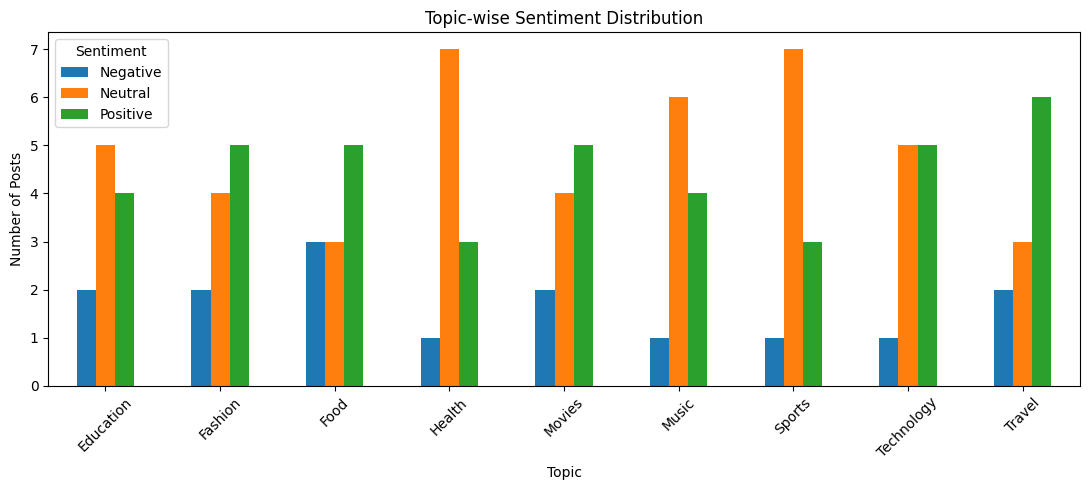

In [25]:
topic_sentiment.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Topic-wise Sentiment Distribution")
plt.xlabel("Topic")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [26]:

df["Date"] = pd.to_datetime(df["Date"])


daily_posts = df.groupby("Date").size()

print("Posts per Day:")
print(daily_posts)

Posts per Day:
Date
2026-07-20    4
2026-07-21    4
2026-07-22    4
2026-07-23    4
2026-07-24    4
2026-07-25    4
2026-07-26    4
2026-07-27    4
2026-07-28    4
2026-07-29    4
2026-07-30    4
2026-07-31    4
2026-08-01    4
2026-08-02    4
2026-08-03    4
2026-08-04    4
2026-08-05    4
2026-08-06    4
2026-08-07    4
2026-08-08    4
2026-08-09    4
2026-08-10    4
2026-08-11    4
2026-08-12    4
2026-08-13    3
dtype: int64


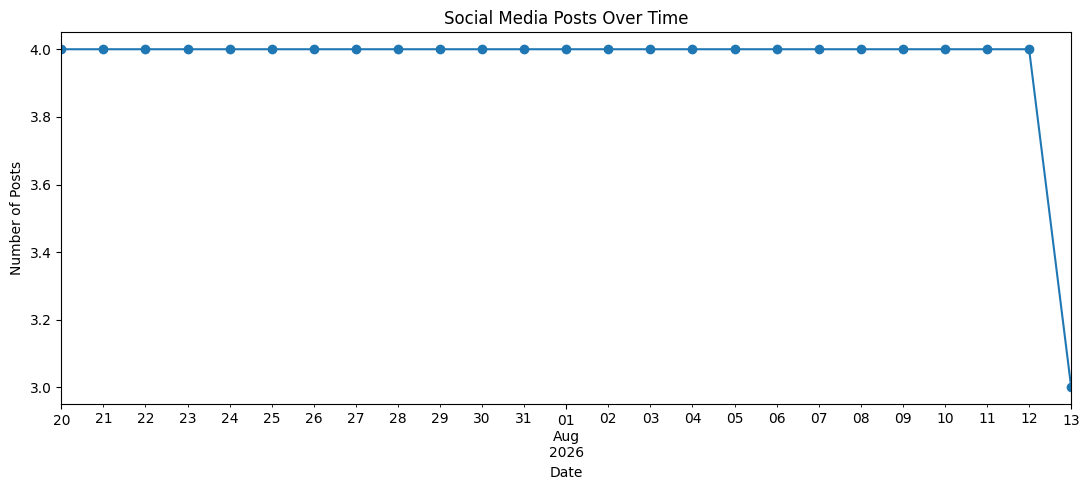

In [27]:
plt.figure(figsize=(11, 5))

daily_posts.plot(
    marker="o"
)

plt.title("Social Media Posts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Posts")

plt.tight_layout()
plt.show()

In [28]:
most_popular_topic = df["Topic"].value_counts().idxmax()

print(
    "Most Discussed Topic:",
    most_popular_topic
)

Most Discussed Topic: Technology


In [29]:
highest_engagement_topic = engagement.idxmax()

print(
    "Highest Engagement Topic:",
    highest_engagement_topic
)

print(
    "Average Engagement:",
    round(engagement.max(), 2)
)

Highest Engagement Topic: Sports
Average Engagement: 486.18


In [30]:
most_common_sentiment = sentiment_counts.idxmax()

print(
    "Most Common Sentiment:",
    most_common_sentiment
)

Most Common Sentiment: Neutral


In [31]:
print("=" * 50)
print("SOCIAL MEDIA TREND ANALYSIS")
print("=" * 50)

print("\nTotal Posts:", len(df))

print(
    "\nMost Discussed Topic:",
    most_popular_topic
)

print(
    "Highest Engagement Topic:",
    highest_engagement_topic
)

print(
    "Highest Average Engagement:",
    round(engagement.max(), 2)
)
print(
    "Most Common Sentiment:",
    most_common_sentiment
)

print(
    "\nMost Popular Hashtag:",
    hashtag_counts.index[0]
)

print("\nSentiment Results:")
print(sentiment_counts)

print("\nTopic Results:")
print(topic_counts)

print("\nProject Analysis Completed Successfully!")

SOCIAL MEDIA TREND ANALYSIS

Total Posts: 99

Most Discussed Topic: Technology
Highest Engagement Topic: Sports
Highest Average Engagement: 486.18
Most Common Sentiment: Neutral

Most Popular Hashtag: #technology

Sentiment Results:
Sentiment
Neutral     44
Positive    40
Negative    15
Name: count, dtype: int64

Topic Results:
Topic
Technology    11
Sports        11
Music         11
Movies        11
Travel        11
Food          11
Fashion       11
Education     11
Health        11
Name: count, dtype: int64

Project Analysis Completed Successfully!
